# Primera serie descriptiva: costo relativo del straddle ATM SPY

## Objetivo

Construir una fila contemporánea por sesión a partir de cadenas originales: el punto medio conjunto de una call y put de igual strike y vencimiento, normalizado por el cierre SPY sin ajustar de la fecha t. Es una serie descriptiva, **no** volatilidad implícita, pago terminal, señal, benchmark ni evaluación predictiva.

## Reglas fijadas antes de ejecutar

- Cadenas originales de solo lectura y cierre SPY sin ajustar de t.
- Duplicado `contractID` idéntico: se conserva una copia; duplicado conflictivo: el proceso se detiene sin escribir CSV.
- Call y put con igual strike y vencimiento, 27–33 DTE.
- En ambos lados: bid > 0, ask ≥ bid y spread relativo `(ask-bid)/mid` ≤ 10%.
- Selección: DTE más cercano a 30, luego strike más cercano a SPY; empates por vencimiento anterior, strike menor y `contractID` léxico.
- `straddle_mid_rel_t = (call_mid + put_mid) / SPY_close_t`.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root / 'scripts'))
from build_atm30_straddle_mid_series import build_series, ConflictingContractIDError
print('Lógica reutilizable: scripts/build_atm30_straddle_mid_series.py')

Lógica reutilizable: scripts/build_atm30_straddle_mid_series.py


In [2]:
# Solo datos contemporáneos: el módulo no lee retornos posteriores, vencimientos ni benchmarks.
try:
    result = build_series(write_csv=True)
except ConflictingContractIDError as exc:
    raise RuntimeError(f'Proceso detenido por política de duplicados: {exc}')

series = result['series'].copy()
series['observation_date'] = pd.to_datetime(series['observation_date'])
print('CSV escrito:', result['output_path'])
print('Reglas:', result['rules'])
print(f'Filas: {len(series):,}; pares seleccionados: {series.pair_available.sum():,}; ausencias: {(~series.pair_available).sum():,}')

CSV escrito: C:\Users\avazq\OneDrive\Escritorio\cienciadatos\portafolio\quant-research-notes\opciones_notas\straddle_ATM_SPY_volatilidad_futura\data\derived\spy_atm30_straddle_mid_rel_2020-01-02_2026-08-31.csv
Reglas: {'dte_range': '27-33', 'target_dte': 30, 'max_relative_spread': 0.1, 'spot_field': 'unadjusted close at t', 'duplicate_policy': 'retain one identical copy; stop on any conflict'}
Filas: 1,674; pares seleccionados: 1,672; ausencias: 2


## Cobertura tras cada filtro

Los conteos son por sesión: tener varios pares no incrementa la cobertura. Las columnas son acumulativas y no cambian las reglas si una etapa reduce la muestra.

In [3]:
coverage = pd.concat([result['coverage_by_year'], result['coverage_total']], ignore_index=True)
filter_columns = [
    'after_identical_dedup', 'same_strike_expiration_pair_27_33_dte',
    'valid_bid_ask_both_options', 'relative_spread_le_10pct_both_options', 'selected_pair'
]
for column in filter_columns:
    coverage[f'{column}_pct'] = 100 * coverage[column] / coverage['sessions']
display(coverage)

absence = series.loc[~series['pair_available'], ['observation_date', 'absence_reason', 'source_file']]
display(Markdown(f'**Fechas sin par seleccionado:** {len(absence)}'))
display(absence)

,year,sessions,after_identical_dedup,same_strike_expiration_pair_27_33_dte,valid_bid_ask_both_options,relative_spread_le_10pct_both_options,selected_pair,identical_duplicate_extra_rows,after_identical_dedup_pct,same_strike_expiration_pair_27_33_dte_pct,valid_bid_ask_both_options_pct,relative_spread_le_10pct_both_options_pct,selected_pair_pct
0,2020,253,253,252,252,252,252,9282,100.0,99.604743,99.604743,99.604743,99.604743
1,2021,252,252,252,252,251,251,0,100.0,100.000000,100.000000,99.603175,99.603175
2,2022,251,251,251,251,251,251,0,100.0,100.000000,100.000000,100.000000,100.000000
3,2023,250,250,250,250,250,250,0,100.0,100.000000,100.000000,100.000000,100.000000
4,2024,252,252,252,252,252,252,0,100.0,100.000000,100.000000,100.000000,100.000000
5,2025,250,250,250,250,250,250,0,100.0,100.000000,100.000000,100.000000,100.000000
6,2026,166,166,166,166,166,166,0,100.0,100.000000,100.000000,100.000000,100.000000
7,TOTAL,1674,1674,1673,1673,1672,1672,9282,100.0,99.940263,99.940263,99.880526,99.880526


**Fechas sin par seleccionado:** 2

,observation_date,absence_reason,source_file
119,2020-06-23,no_same_strike_expiration_pair_27_33_dte,C:\Users\avazq\OneDrive\Escritorio\cienciadato...
480,2021-11-26,no_pair_passing_relative_spread_10pct,C:\Users\avazq\OneDrive\Escritorio\cienciadato...


### Interpretación

La serie conserva todas las sesiones de cadena, incluso las que no pasan los filtros. La ausencia es información de calidad y no se rellena ni se elimina de forma silenciosa.

In [4]:
# Ejemplos trazables: primera sesión, sesión central y última sesión de la serie.
anchors = series.iloc[[0, (len(series) - 1) // 2, -1]].copy()
example_columns = [
    'observation_date', 'source_file', 'pair_available', 'absence_reason', 'spy_close_t',
    'call_contractID', 'put_contractID', 'expiration', 'dte', 'strike',
    'call_bid', 'call_ask', 'call_mid', 'call_relative_spread',
    'put_bid', 'put_ask', 'put_mid', 'put_relative_spread', 'straddle_mid_rel_t'
]
display(anchors[example_columns])

,observation_date,source_file,pair_available,absence_reason,spy_close_t,call_contractID,put_contractID,expiration,dte,strike,call_bid,call_ask,call_mid,call_relative_spread,put_bid,put_ask,put_mid,put_relative_spread,straddle_mid_rel_t
0,2020-01-02,C:\Users\avazq\OneDrive\Escritorio\cienciadato...,True,None,324.87,SPY200131C00325000,SPY200131P00325000,2020-01-31,29.0,325.0,3.88,3.91,3.895,0.007702,3.51,3.54,3.525,0.008511,0.022840
836,2023-04-28,C:\Users\avazq\OneDrive\Escritorio\cienciadato...,True,None,415.93,SPY230526C00416000,SPY230526P00416000,2023-05-26,28.0,416.0,7.05,7.07,7.060,0.002833,5.47,5.49,5.480,0.003650,0.030149
1673,2026-08-31,C:\Users\avazq\OneDrive\Escritorio\cienciadato...,True,None,767.05,SPY260930C00767000,SPY260930P00767000,2026-09-30,30.0,767.0,10.82,10.87,10.845,0.004610,10.03,10.08,10.055,0.004973,0.027247


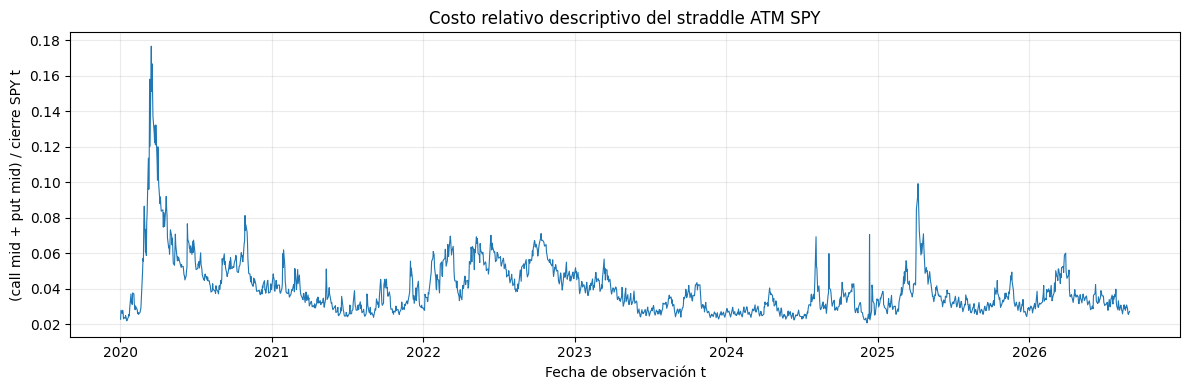

,dte,call_relative_spread,put_relative_spread,straddle_mid_rel_t
count,1672.000000,1672.000000,1672.000000,1672.000000
mean,29.869019,0.007751,0.008297,0.040075
5%,28.000000,0.002608,0.002654,0.025116
50%,30.000000,0.005241,0.005891,0.035992
95%,32.000000,0.018751,0.023149,0.065210
max,32.000000,0.098246,0.095306,0.176673


In [5]:
selected = series.loc[series['pair_available']].copy()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(selected['observation_date'], selected['straddle_mid_rel_t'], linewidth=0.8, color='#1f77b4')
ax.set(title='Costo relativo descriptivo del straddle ATM SPY', xlabel='Fecha de observación t',
       ylabel='(call mid + put mid) / cierre SPY t')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

display(selected[['dte', 'call_relative_spread', 'put_relative_spread', 'straddle_mid_rel_t']].describe(
    percentiles=[.05, .5, .95]
).loc[['count', 'mean', '5%', '50%', '95%', 'max']])

## Límites

La hora de cotización/publicación EOD no está verificada. Por ello, la serie describe datos etiquetados con fecha t; no demuestra que ambos puntos medios estuvieran disponibles antes de la siguiente sesión ni que pudieran ejecutarse simultáneamente. No se han leído precios ni retornos posteriores a t, y no se han calculado pagos a vencimiento, benchmark histórico, señal o métricas predictivas.

## Mis notas

- 
- 
- 